In [ ]:
!pip install yfinance
!pip install pandas

In [ ]:
# ดึงข้อมูล
import yfinance as yf

# จัดการข้อมูล
import pandas as pd
import numpy as np

# วาดกราฟ
import matplotlib.pyplot as plt

# สถิติ
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

In [ ]:
OIL = yf.download('CL=F', start = '2020-01-01')
DXY = yf.download('DX-Y.NYB', start = '2020-01-01')
SP500 = yf.download('^GSPC', start = '2020-01-01')

/tmp/ipykernel_563/3323068976.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  OIL = yf.download('CL=F', start = '2020-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_563/3323068976.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  DXY = yf.download('DX-Y.NYB', start = '2020-01-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_563/3323068976.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  SP500 = yf.download('^GSPC', start = '2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [ ]:
OIL.info()
DXY.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1617 entries, 2020-01-02 to 2026-06-05
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, CL=F)   1617 non-null   float64
 1   (High, CL=F)    1617 non-null   float64
 2   (Low, CL=F)     1617 non-null   float64
 3   (Open, CL=F)    1617 non-null   float64
 4   (Volume, CL=F)  1617 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 75.8 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1616 entries, 2020-01-02 to 2026-06-05
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, DX-Y.NYB)   1616 non-null   float64
 1   (High, DX-Y.NYB)    1616 non-null   float64
 2   (Low, DX-Y.NYB)     1616 non-null   float64
 3   (Open, DX-Y.NYB)    1616 non-null   float64
 4   (Volume, DX-Y.NYB)  1616 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 

In [ ]:
OIL['return'] = OIL['Close'].pct_change() * 100

In [ ]:
DXY['return'] = DXY['Close'].pct_change() * 100
SP500['return'] = SP500['Close'].pct_change() * 100

/tmp/ipykernel_563/1763610588.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  SP500['return'] = SP500['Close'].pct_change() * 100


<Axes: title={'center': 'OIL_RETURN'}, xlabel='Date'>

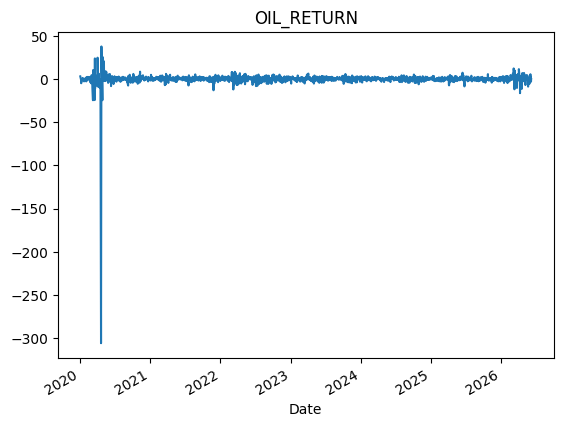

In [ ]:
OIL['return'].plot(
    title = 'OIL_RETURN'
)


<Axes: title={'center': 'DXY_RETURN'}, xlabel='Date'>

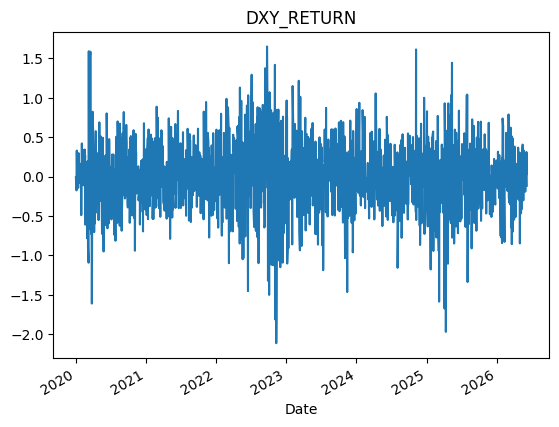

In [ ]:
DXY['return'].plot(title = 'DXY_RETURN')

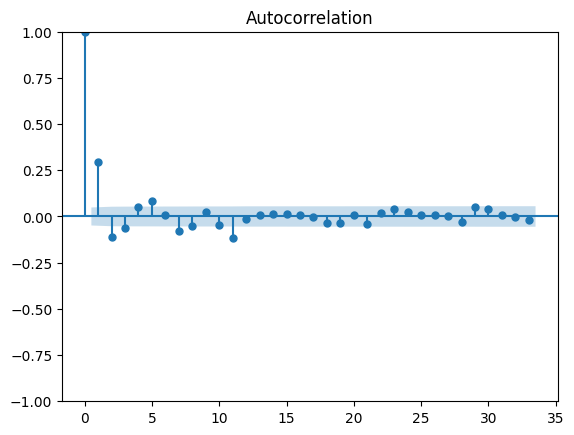

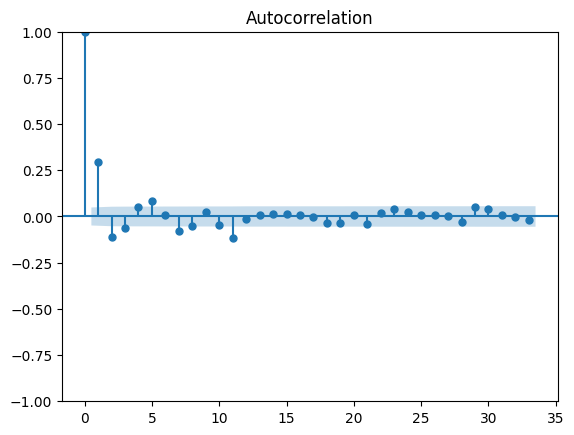

In [ ]:
plot_acf(OIL['return'].dropna())

In [ ]:
x = sm.add_constant(df[['DXY','SP500']])
model = sm.OLS(df['OIL'], x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    OIL   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     11.03
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           1.74e-05
Time:                        04:22:43   Log-Likelihood:                -5797.4
No. Observations:                1612   AIC:                         1.160e+04
Df Residuals:                    1609   BIC:                         1.162e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1987      0.220     -0.902      0.3

In [ ]:
df = pd.DataFrame({
   "OIL" : OIL['return'],
   "DXY" : DXY['return'],
   "SP500" : SP500['return']
 }).dropna()